# EDA — Dataset simulado BLE Indoor

Exploración del dataset de entrenamiento generado para un experimento específico.
Carga el CSV de trayectorias y analiza:

1. Cobertura espacial y balance de zonas
2. Distribución RSSI por gateway
3. Visibilidad de gateways y receptión
4. Separabilidad de zonas en el espacio RSSI
5. RSSI vs distancia al gateway
6. Comparación path loss vs Sionna RT (si ambos datasets existen)

In [20]:
%matplotlib inline
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config" / "baseline_room.yaml").is_file():
    REPO_ROOT = Path.cwd().parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ble_indoor.models.knn_zone import ZONE_ID_COLUMN
from ble_indoor.settings import ProjectConfig, ProjectLayout
from ble_indoor.simulation.trace_loader import load_training_trace

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)

layout = ProjectLayout(REPO_ROOT)
CONFIGS_DIR = REPO_ROOT / "experiments" / "configs"
print("Experimentos disponibles:")
for p in sorted(CONFIGS_DIR.glob("*.yaml")):
    csv = REPO_ROOT / "data" / "simulated" / p.stem / "training_trace.csv"
    status = "CSV" if csv.is_file() else "sin CSV"
    print(f"  · {p.stem:<30}  [{status}]")

Experimentos disponibles:
  · corners_3gw_12x8                [CSV]
  · corners_4gw_12x8                [CSV]
  · corners_4gw_20x12               [CSV]
  · corners_6gw_12x8                [CSV]
  · extreme_4gw_12x8                [CSV]
  · random_4gw_12x8                 [CSV]
  · wall_center_4gw_12x8            [CSV]


In [21]:
# ── elige el experimento ──────────────────────────────────────────────────────
EXP = "corners_4gw_12x8"
# EXP = "corners_6gw_12x8"
# EXP = "corners_3gw_12x8"
# EXP = "corners_4gw_20x12"
# EXP = "extreme_4gw_12x8"
# EXP = "random_4gw_12x8"
# EXP = "wall_center_4gw_12x8"
# ─────────────────────────────────────────────────────────────────────────────

cfg_path  = CONFIGS_DIR / f"{EXP}.yaml"
cfg       = ProjectConfig.load(cfg_path)
env       = cfg.environment
csv_path  = layout.resolve_repo_path(cfg.training_data.training_trace_csv)

assert csv_path.is_file(), (
    f"CSV no encontrado: {csv_path}\n"
    f"Generalo con: PYTHONPATH=src python -m ble_indoor generate-csv --config {cfg_path} --force"
)

df = load_training_trace(csv_path, env, cfg.spatial_zones)

rssi_cols   = [f"rssi_{g}" for g in env.gateway_ids]
missing_dbm = float(cfg.trajectory.missing_rssi_dbm)
room_w      = env.room.width_m
room_h      = env.room.height_m
n_zones     = cfg.spatial_zones.n_zones
zone_labels = cfg.spatial_zones.zone_labels()

print(f"Experimento : {EXP}")
print(f"CSV         : {csv_path}")
print(f"Filas       : {len(df):,}")
print(f"Habitación  : {room_w}m × {room_h}m")
print(f"Gateways    : {env.gateway_ids}")
print(f"Zonas       : {cfg.spatial_zones.nx}×{cfg.spatial_zones.ny} = {n_zones}")
print(f"Missing dBm : {missing_dbm}")
df.head(3)

Experimento : corners_4gw_12x8
CSV         : /Users/joelibaceta/Projects/ble-indoor-ondevice-localization/data/simulated/corners_4gw_12x8/training_trace.csv
Filas       : 4,035
Habitación  : 12.0m × 8.0m
Gateways    : ('A1', 'A2', 'A3', 'A4')
Zonas       : 3×2 = 6
Missing dBm : -105.0


,session_id,x_m,y_m,zone_id,zone_name,n_visible,rssi_A1,rssi_A2,rssi_A3,rssi_A4
0,0,8.784969,3.370933,2,Z0_2,3,-82.937929,-69.862142,-105.000000,-72.878658
1,0,8.897693,3.067684,2,Z0_2,3,-81.639598,-68.225721,-82.679674,-105.000000
2,0,8.504860,3.032471,2,Z0_2,3,-76.998737,-105.000000,-78.196718,-72.467017


## 1. Layout del experimento

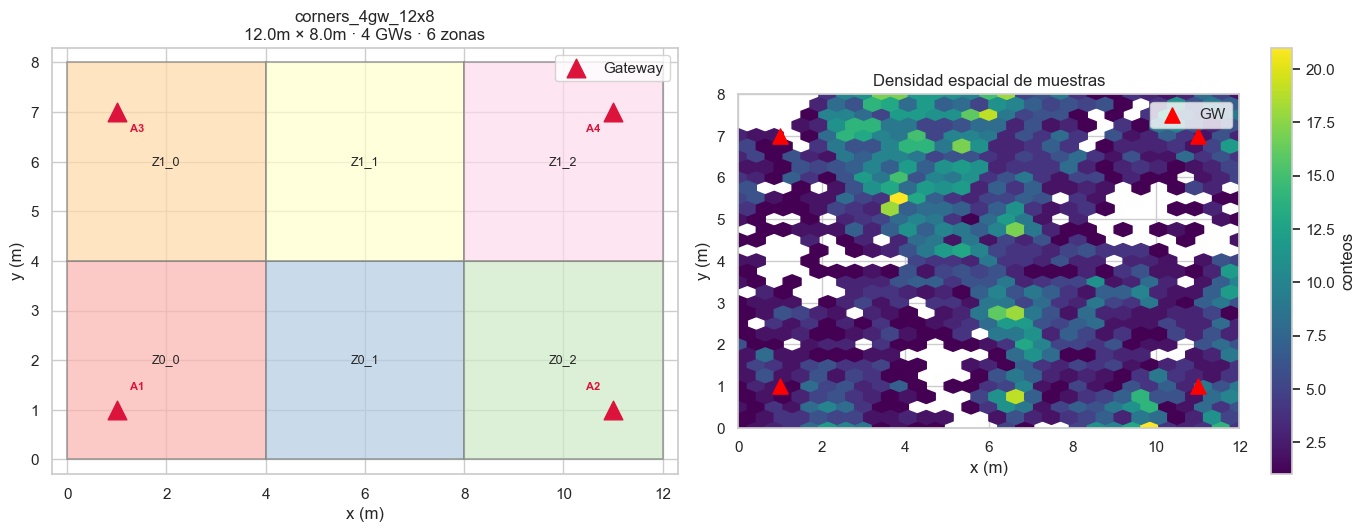

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Mapa de zonas y gateways
ax = axes[0]
nx, ny = cfg.spatial_zones.nx, cfg.spatial_zones.ny
cell_w, cell_h = room_w / nx, room_h / ny
colors = plt.cm.Pastel1(np.linspace(0, 0.8, n_zones))
for iy in range(ny):
    for ix in range(nx):
        zid = iy * nx + ix
        ax.add_patch(mpatches.FancyBboxPatch(
            (ix * cell_w, iy * cell_h), cell_w, cell_h,
            boxstyle="square,pad=0", linewidth=1.2,
            edgecolor="gray", facecolor=colors[zid], alpha=0.7,
        ))
        ax.text(ix*cell_w + cell_w/2, iy*cell_h + cell_h/2,
                zone_labels[zid], ha="center", va="center", fontsize=9)

gw_pos = env.gateway_positions_m()
ax.scatter(gw_pos[:, 0], gw_pos[:, 1], c="crimson", s=180, zorder=5,
           marker="^", label="Gateway")
for gw in env.gateways:
    ox = 0.4 if gw.x_m <= room_w/2 else -0.4
    oy = 0.4 if gw.y_m <= room_h/2 else -0.4
    ax.text(gw.x_m+ox, gw.y_m+oy, gw.id, fontsize=8,
            fontweight="bold", color="crimson", ha="center")
ax.set_xlim(-0.3, room_w+0.3); ax.set_ylim(-0.3, room_h+0.3)
ax.set_aspect("equal"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title(f"{EXP}\n{room_w}m × {room_h}m · {len(env.gateways)} GWs · {n_zones} zonas")
ax.legend(loc="upper right")

# — Densidad de muestras
ax2 = axes[1]
hb = ax2.hexbin(df["x_m"], df["y_m"], gridsize=28, cmap="viridis", mincnt=1)
ax2.scatter(gw_pos[:,0], gw_pos[:,1], c="red", s=120, marker="^", zorder=5, label="GW")
ax2.set_xlim(0, room_w); ax2.set_ylim(0, room_h)
ax2.set_aspect("equal"); ax2.set_xlabel("x (m)"); ax2.set_ylabel("y (m)")
ax2.set_title("Densidad espacial de muestras")
plt.colorbar(hb, ax=ax2, label="conteos")
ax2.legend()

plt.tight_layout()
plt.show()

## 2. Balance de clases y trayectorias

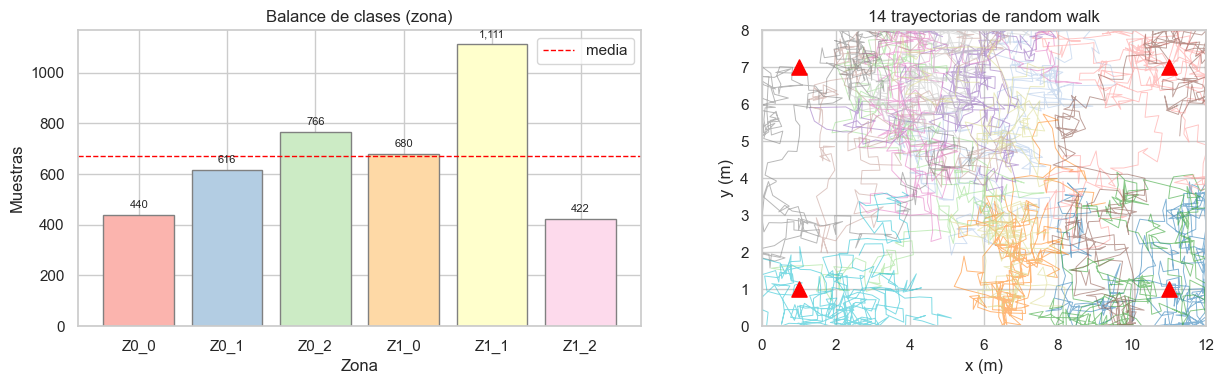

Total: 4,035 filas | 6 zonas | Balance min/max: 422 / 1,111 (ratio 2.63×)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Muestras por zona
ax = axes[0]
zc = df[ZONE_ID_COLUMN].value_counts().sort_index()
bars = ax.bar([zone_labels[i] for i in zc.index], zc.values,
               color=plt.cm.Pastel1(np.linspace(0, 0.8, n_zones)), edgecolor="gray")
ax.axhline(len(df) / n_zones, color="red", linestyle="--", linewidth=1, label="media")
ax.set_xlabel("Zona"); ax.set_ylabel("Muestras")
ax.set_title("Balance de clases (zona)")
ax.legend()
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)

# Trayectorias por sesión
ax2 = axes[1]
if "session_id" in df.columns:
    cmap = plt.cm.tab20
    sessions = df["session_id"].unique()
    for sid in sessions:
        grp = df[df.session_id == sid]
        ax2.plot(grp["x_m"], grp["y_m"], lw=0.7, alpha=0.55,
                 color=cmap(int(sid) / max(len(sessions), 1)))
    ax2.scatter(gw_pos[:,0], gw_pos[:,1], c="red", s=120, marker="^", zorder=5)
    ax2.set_xlim(0, room_w); ax2.set_ylim(0, room_h)
    ax2.set_aspect("equal"); ax2.set_xlabel("x (m)"); ax2.set_ylabel("y (m)")
    ax2.set_title(f"{len(sessions)} trayectorias de random walk")
else:
    ax2.text(0.5, 0.5, "sin session_id", transform=ax2.transAxes, ha="center")

plt.tight_layout()
plt.show()

print(f"Total: {len(df):,} filas | {df[ZONE_ID_COLUMN].nunique()} zonas | "
      f"Balance min/max: {zc.min():,} / {zc.max():,} "
      f"(ratio {zc.max()/zc.min():.2f}×)")

## 3. Distribución RSSI por gateway

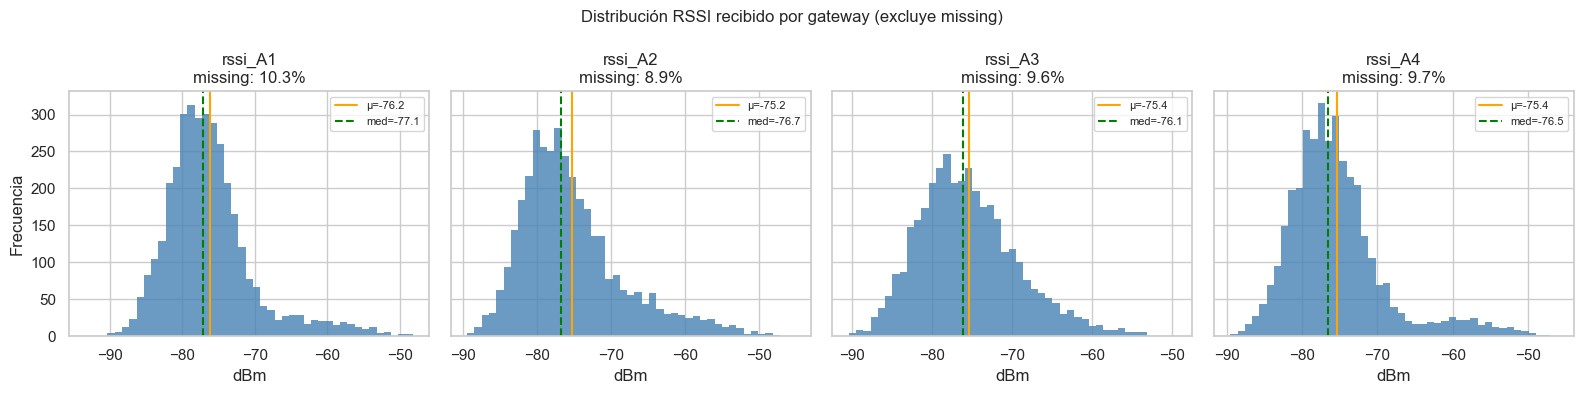

,count,mean,std,min,50%,max,missing_%
rssi_A1,3621.0,-76.2,6.2,-93.3,-77.1,-48.2,10.260223
rssi_A2,3677.0,-75.2,7.1,-89.5,-76.7,-45.2,8.872367
rssi_A3,3649.0,-75.4,6.3,-90.4,-76.1,-49.5,9.566295
rssi_A4,3642.0,-75.4,6.5,-89.5,-76.5,-46.1,9.739777


In [24]:
n_gw = len(rssi_cols)
fig, axes = plt.subplots(1, n_gw, figsize=(4*n_gw, 4), sharey=True)
if n_gw == 1:
    axes = [axes]

for ax, col in zip(axes, rssi_cols):
    received = df[col][df[col] > missing_dbm + 0.5]
    missing_frac = (df[col] <= missing_dbm + 0.5).mean()
    ax.hist(received, bins=45, color="steelblue", alpha=0.8, edgecolor="none")
    ax.axvline(received.mean(), color="orange", linewidth=1.5,
               label=f"μ={received.mean():.1f}")
    ax.axvline(received.median(), color="green", linewidth=1.5, linestyle="--",
               label=f"med={received.median():.1f}")
    ax.set_title(f"{col}\nmissing: {missing_frac:.1%}")
    ax.set_xlabel("dBm")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frecuencia")
plt.suptitle("Distribución RSSI recibido por gateway (excluye missing)", fontsize=12)
plt.tight_layout()
plt.show()

# Tabla resumen
stats = pd.DataFrame({
    col: df[col][df[col] > missing_dbm + 0.5].describe()
    for col in rssi_cols
}).T.round(1)
stats["missing_%"] = [(df[c] <= missing_dbm + 0.5).mean() * 100 for c in rssi_cols]
try:
    from IPython.display import display as ipy_display
    ipy_display(stats[["count", "mean", "std", "min", "50%", "max", "missing_%"]])
except Exception:
    print(stats)

## 4. Visibilidad de gateways

Número de gateways visibles por muestra y mapa espacial de receptión.

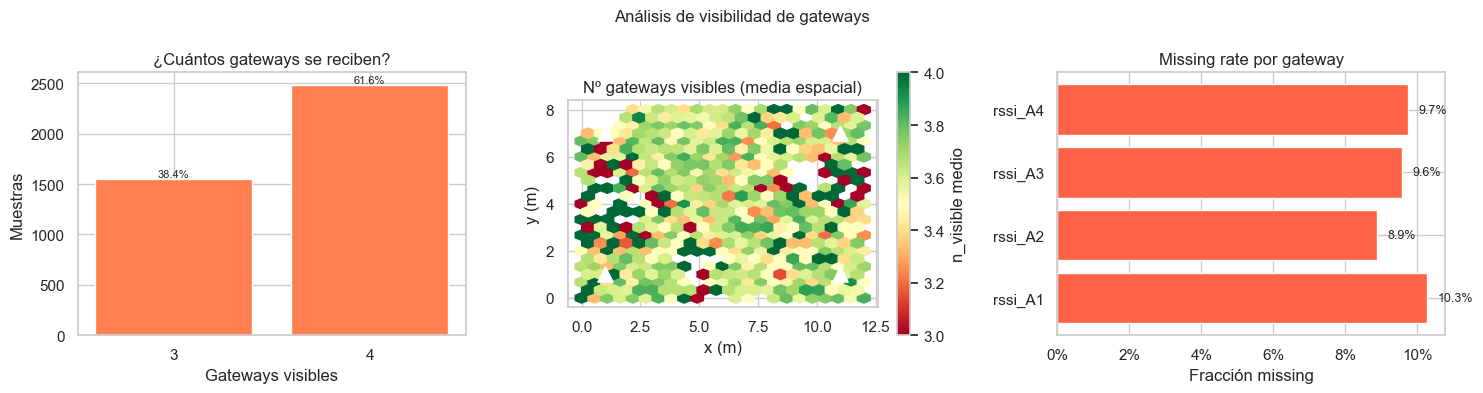

Missing rate global: 9.6%
Muestras con todos visibles: 61.6%
Muestras con al menos 1 missing: 38.4%


In [25]:
visible_per_row = (df[rssi_cols] > missing_dbm + 0.5).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# n_visible distribution
ax = axes[0]
vc = visible_per_row.value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color="coral", edgecolor="white")
ax.set_xlabel("Gateways visibles")
ax.set_ylabel("Muestras")
ax.set_title("¿Cuántos gateways se reciben?")
for k, v in vc.items():
    ax.text(str(k), v+20, f"{v/len(df):.1%}", ha="center", fontsize=8)

# Mapa espacial de n_visible medio
ax2 = axes[1]
im = ax2.hexbin(df["x_m"], df["y_m"], C=visible_per_row,
                gridsize=22, cmap="RdYlGn", reduce_C_function=np.mean,
                extent=(0, room_w, 0, room_h))
ax2.scatter(gw_pos[:,0], gw_pos[:,1], c="white", s=120, marker="^", zorder=5)
ax2.set_aspect("equal"); ax2.set_xlabel("x (m)"); ax2.set_ylabel("y (m)")
ax2.set_title("Nº gateways visibles (media espacial)")
plt.colorbar(im, ax=ax2, label="n_visible medio")

# Fracción de missing por gateway
ax3 = axes[2]
miss_frac = [(df[c] <= missing_dbm + 0.5).mean() for c in rssi_cols]
bars = ax3.barh(rssi_cols, miss_frac, color="tomato", edgecolor="white")
ax3.set_xlabel("Fracción missing")
ax3.set_title("Missing rate por gateway")
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for bar, v in zip(bars, miss_frac):
    ax3.text(v+0.003, bar.get_y()+bar.get_height()/2,
             f"{v:.1%}", va="center", fontsize=9)

plt.suptitle("Análisis de visibilidad de gateways", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Missing rate global: {(df[rssi_cols] <= missing_dbm+0.5).values.mean():.1%}")
print(f"Muestras con todos visibles: {(visible_per_row == n_gw).mean():.1%}")
print(f"Muestras con al menos 1 missing: {(visible_per_row < n_gw).mean():.1%}")

## 5. RSSI vs distancia al gateway

Sanidad del canal: se espera tendencia decreciente. El ruido y el multipath añaden dispersión.

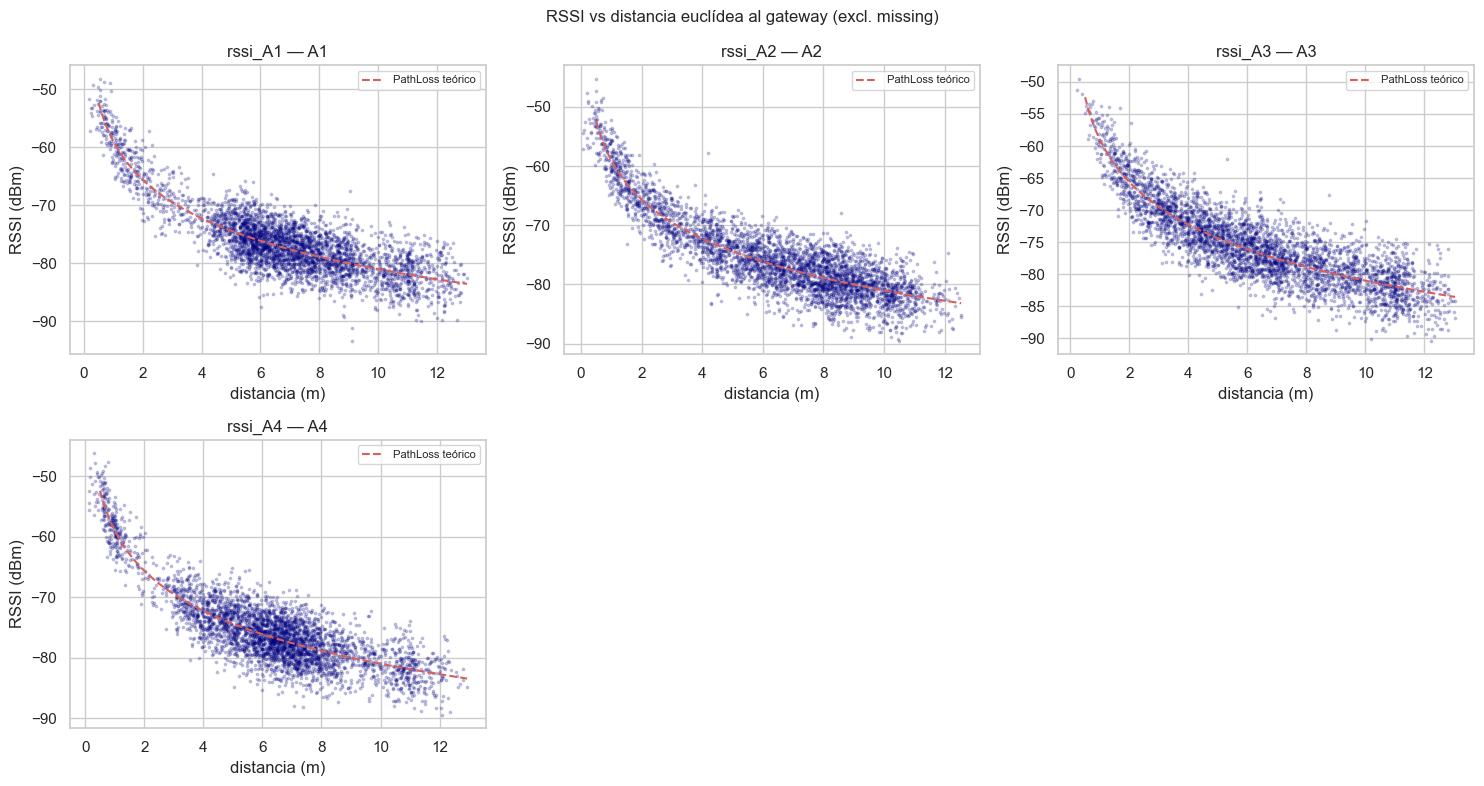

In [26]:
xy = df[["x_m", "y_m"]].to_numpy(dtype=np.float64)
n_gw = len(rssi_cols)
ncols = min(n_gw, 3)
nrows = (n_gw + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes_flat = axes.ravel()

for ax, col, gw in zip(axes_flat, rssi_cols, env.gateways):
    gxy = np.array([gw.x_m, gw.y_m])
    d = np.linalg.norm(xy - gxy, axis=1)
    received = df[col] > missing_dbm + 0.5
    ax.scatter(d[received], df.loc[received, col],
               s=3, alpha=0.2, c="navy", rasterized=True)

    # Curva de path loss teórica
    d_line = np.linspace(0.5, d.max(), 200)
    rssi_theory = gw.tx_power_dbm - 10 * env.rssi_model.path_loss_exponent * np.log10(d_line)
    ax.plot(d_line, rssi_theory, "r--", linewidth=1.5, label="PathLoss teórico")

    ax.set_xlabel("distancia (m)")
    ax.set_ylabel("RSSI (dBm)")
    ax.set_title(f"{col} — {gw.id}")
    ax.legend(fontsize=8)

for ax in axes_flat[n_gw:]:
    ax.set_visible(False)

plt.suptitle("RSSI vs distancia euclídea al gateway (excl. missing)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. RSSI por zona — separabilidad

Boxplots de cada gateway por zona. Si las distribuciones se solapan mucho, el clasificador tendrá dificultades.

/var/folders/yz/81l4y8wj0dq706mv_7qpm5kw0000gn/T/ipykernel_35514/3664395386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yz/81l4y8wj0dq706mv_7qpm5kw0000gn/T/ipykernel_35514/3664395386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yz/81l4y8wj0dq706mv_7qpm5kw0000gn/T/ipykernel_35514/3664395386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yz/81l4y8wj0dq706mv_7qpm5kw0000gn/T/ipykernel_35514/3664395386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

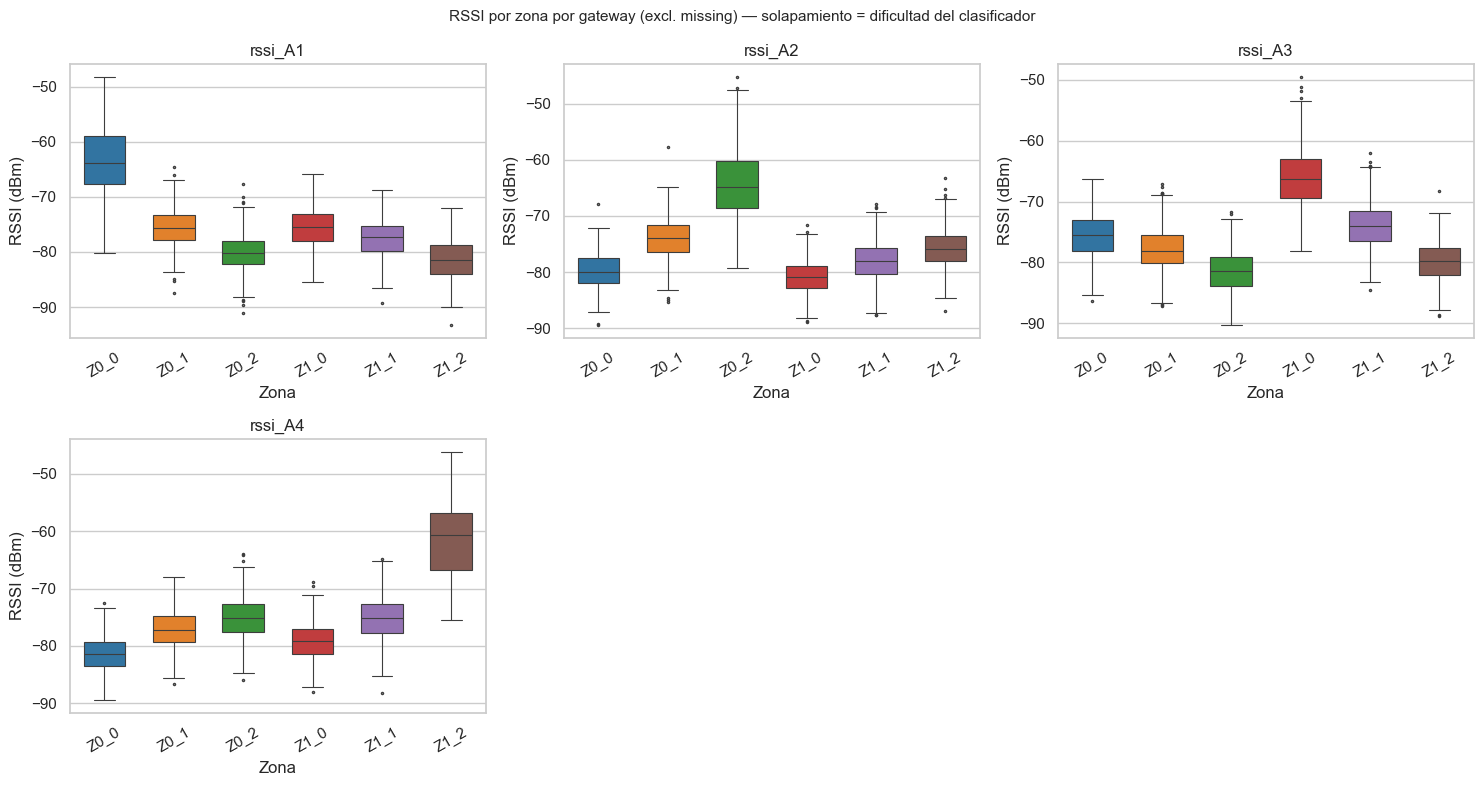

In [27]:
n_gw = len(rssi_cols)
ncols = min(n_gw, 3)
nrows = (n_gw + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes_flat = axes.ravel()

palette = sns.color_palette("tab10", n_zones)
df_box = df.copy()
df_box["zona"] = df[ZONE_ID_COLUMN].map(lambda z: zone_labels[z])

for ax, col in zip(axes_flat, rssi_cols):
    received_mask = df_box[col] > missing_dbm + 0.5
    sns.boxplot(
        data=df_box[received_mask], x="zona", y=col,
        palette=palette, order=zone_labels, ax=ax,
        width=0.6, fliersize=1.5, linewidth=0.8,
    )
    ax.set_xlabel("Zona"); ax.set_ylabel("RSSI (dBm)")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)

for ax in axes_flat[n_gw:]:
    ax.set_visible(False)

plt.suptitle("RSSI por zona por gateway (excl. missing) — solapamiento = dificultad del clasificador",
             fontsize=11)
plt.tight_layout()
plt.show()

## 7. PCA del espacio RSSI — separabilidad global

/var/folders/yz/81l4y8wj0dq706mv_7qpm5kw0000gn/T/ipykernel_35514/329071903.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", n_zones)


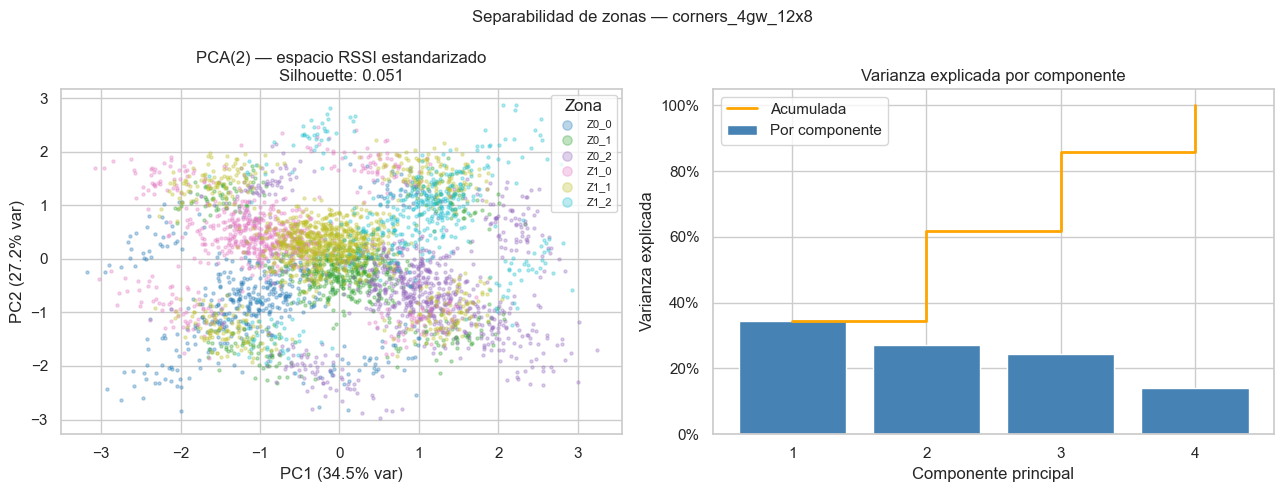

Silhouette score (zonas en espacio RSSI): 0.0508
  → 1.0 = perfectamente separable | 0.0 = solapamiento total
PC1+PC2 explican: 61.7% de la varianza


In [28]:
X = df[rssi_cols].to_numpy(dtype=np.float64)
y = df[ZONE_ID_COLUMN].to_numpy(dtype=np.int64)
Xs = StandardScaler().fit_transform(X)

pca = PCA(n_components=min(4, len(rssi_cols)), random_state=0)
Z = pca.fit_transform(Xs)

# Silhouette score
n_sample = min(5000, len(Xs))
idx = np.random.default_rng(0).choice(len(Xs), n_sample, replace=False)
sil = silhouette_score(Xs[idx], y[idx])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PCA 2D coloreado por zona
ax = axes[0]
palette = plt.cm.get_cmap("tab10", n_zones)
for zid in range(n_zones):
    mask = y == zid
    ax.scatter(Z[mask, 0], Z[mask, 1], s=5, alpha=0.3,
               c=[palette(zid)], label=zone_labels[zid])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title(f"PCA(2) — espacio RSSI estandarizado\nSilhouette: {sil:.3f}")
ax.legend(markerscale=3, fontsize=8, title="Zona")

# Varianza explicada
ax2 = axes[1]
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax2.bar(range(1, len(cumvar)+1), pca.explained_variance_ratio_,
        color="steelblue", label="Por componente")
ax2.step(range(1, len(cumvar)+1), cumvar, where="post",
         color="orange", linewidth=2, label="Acumulada")
ax2.set_xlabel("Componente principal")
ax2.set_ylabel("Varianza explicada")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.set_title("Varianza explicada por componente")
ax2.set_xticks(range(1, len(cumvar)+1))
ax2.legend()

plt.suptitle(f"Separabilidad de zonas — {EXP}", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Silhouette score (zonas en espacio RSSI): {sil:.4f}")
print(f"  → 1.0 = perfectamente separable | 0.0 = solapamiento total")
print(f"PC1+PC2 explican: {pca.explained_variance_ratio_[:2].sum():.1%} de la varianza")

## 8. Correlación entre gateways

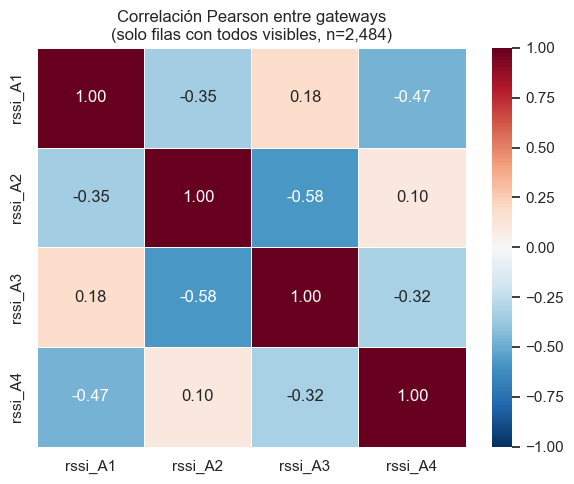

In [29]:
received_mask = (df[rssi_cols] > missing_dbm + 0.5).all(axis=1)
corr = df.loc[received_mask, rssi_cols].corr()

fig, ax = plt.subplots(figsize=(max(5, n_gw+2), max(4, n_gw+1)))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(f"Correlación Pearson entre gateways\n(solo filas con todos visibles, n={received_mask.sum():,})")
plt.tight_layout()
plt.show()

## 9. Comparación path loss vs Sionna RT

Si existe el cache de Sionna RT, compara la distribución RSSI de ambos simuladores para este experimento.

In [30]:
# Intenta cargar el simulador Sionna RT y generar datos en memoria para comparar
# Solo usa el cache ya guardado — no re-corre Sionna si no existe.
cache_path = REPO_ROOT / "data" / "simulated" / EXP / "sionna_rt_cache.npz"

sim_srt = None
if cache_path.is_file():
    try:
        from ble_indoor.simulation.sionna_rt_simulator import SionnaRTSimulator
        sim_srt = SionnaRTSimulator(env, cfg.sionna_rt, layout_root=REPO_ROOT)
        print(f"SionnaRTSimulator cargado desde cache: {cache_path}")
    except ImportError:
        print("Sionna no instalado — comparación omitida.")
else:
    print(f"Cache Sionna RT no encontrado: {cache_path}")
    print("Generalo con: PYTHONPATH=src python -m ble_indoor generate-csv "
          f"--config experiments/configs/{EXP}.yaml --simulator sionna --force")
    print("(La celda de comparación se saltará)")

[SionnaRTSimulator] Loaded precomputed grid from /Users/joelibaceta/Projects/ble-indoor-ondevice-localization/data/simulated/corners_4gw_12x8/sionna_rt_cache.npz
SionnaRTSimulator cargado desde cache: /Users/joelibaceta/Projects/ble-indoor-ondevice-localization/data/simulated/corners_4gw_12x8/sionna_rt_cache.npz


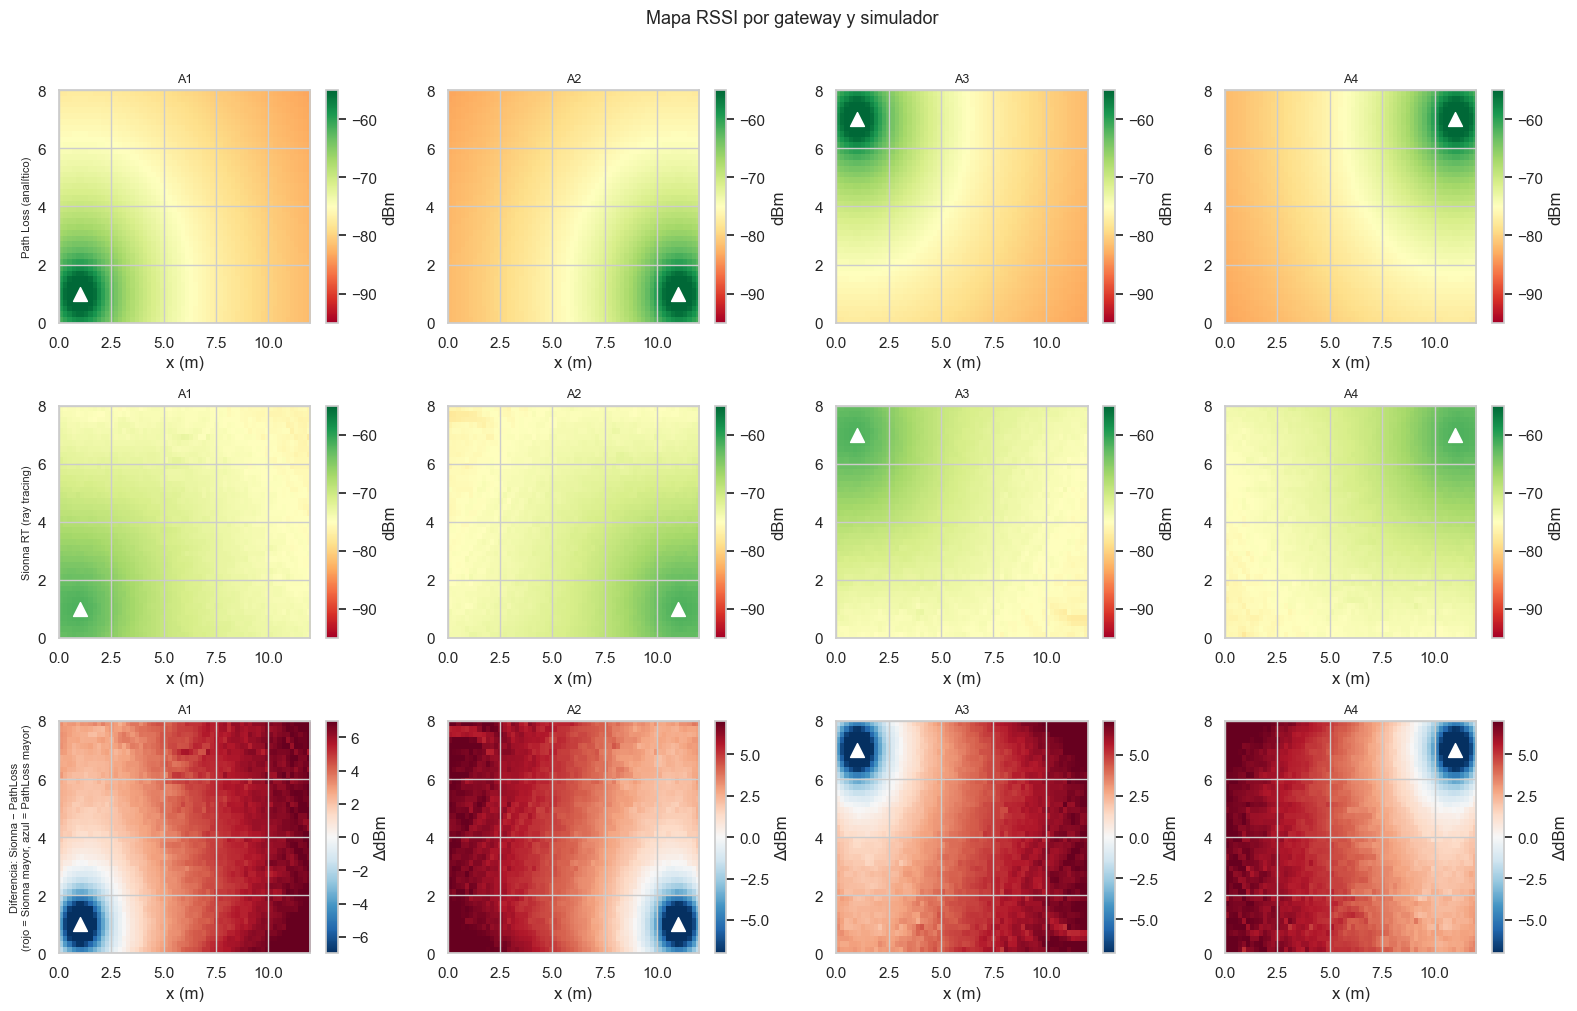

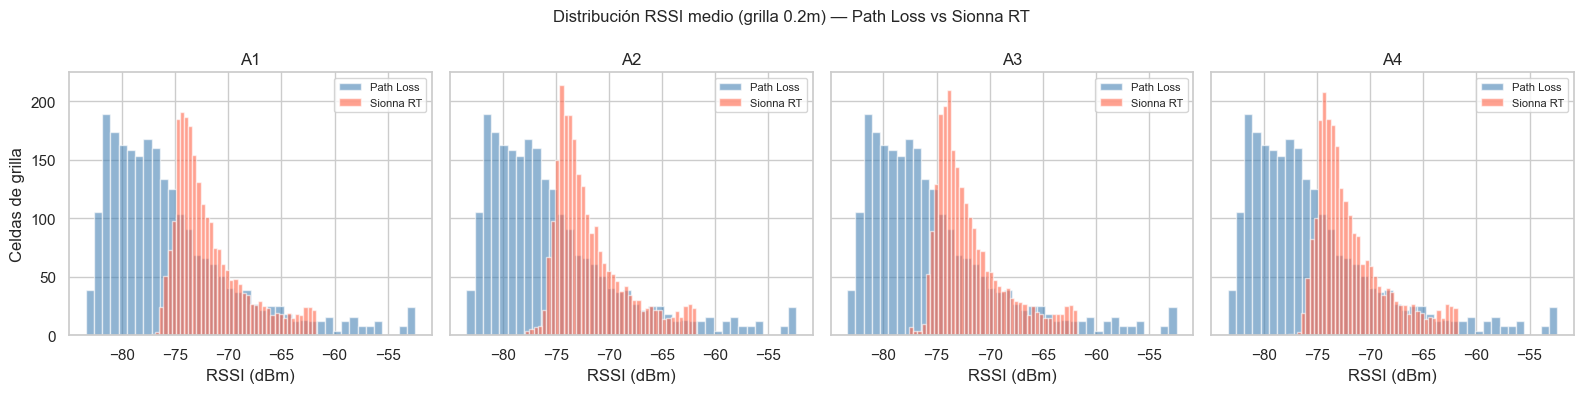

Diferencia Sionna RT − Path Loss por gateway (dBm):
  A1: media=+3.60  std=3.00  p5=-2.1  p95=+6.8
  A2: media=+3.61  std=2.99  p5=-2.1  p95=+6.9
  A3: media=+3.61  std=3.00  p5=-2.1  p95=+6.9
  A4: media=+3.61  std=3.00  p5=-2.1  p95=+6.9


In [31]:
if sim_srt is not None:
    from ble_indoor.simulation.path_loss import PathLossSimulator

    sim_pl = PathLossSimulator(env)
    res = 0.2
    xs = np.arange(res/2, room_w, res)
    ys = np.arange(res/2, room_h, res)
    grid = np.array(np.meshgrid(xs, ys, indexing="ij")).reshape(2, -1).T

    rssi_pl  = np.array([sim_pl.mean_rssi_dbm(p)  for p in grid])
    rssi_srt = np.array([sim_srt.mean_rssi_dbm(p) for p in grid])

    n_gw = len(rssi_cols)
    fig, axes = plt.subplots(3, n_gw, figsize=(4*n_gw, 10))
    if n_gw == 1:
        axes = axes[:, np.newaxis]

    vmin, vmax = -95, -55
    row_titles = [
        "Path Loss (analítico)",
        "Sionna RT (ray tracing)",
        "Diferencia: Sionna − PathLoss\n(rojo = Sionna mayor, azul = PathLoss mayor)",
    ]
    for col_idx, gw in enumerate(env.gateways):
        zpl  = rssi_pl[:, col_idx].reshape(len(xs), len(ys))
        zsrt = rssi_srt[:, col_idx].reshape(len(xs), len(ys))
        diff = zsrt - zpl
        lim  = np.percentile(np.abs(diff), 95)

        for row, (data, cmap, v0, v1, label) in enumerate([
            (zpl,  "RdYlGn", vmin, vmax,  "dBm"),
            (zsrt, "RdYlGn", vmin, vmax,  "dBm"),
            (diff, "RdBu_r", -lim,  lim,  "ΔdBm"),
        ]):
            ax = axes[row][col_idx]
            im = ax.imshow(data.T, origin="lower", aspect="auto",
                           extent=[0, room_w, 0, room_h],
                           cmap=cmap, vmin=v0, vmax=v1)
            ax.scatter([gw.x_m], [gw.y_m], c="white", s=100, marker="^", zorder=5)
            ax.set_title(f"{gw.id}", fontsize=9)
            ax.set_xlabel("x (m)")
            if col_idx == 0:
                ax.set_ylabel(row_titles[row], fontsize=8)
            plt.colorbar(im, ax=ax, label=label)

    plt.suptitle("Mapa RSSI por gateway y simulador", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # Distribuciones superpuestas por gateway
    fig, axes = plt.subplots(1, n_gw, figsize=(4*n_gw, 4), sharey=True)
    if n_gw == 1:
        axes = [axes]
    for ax, col_idx, gw in zip(axes, range(n_gw), env.gateways):
        ax.hist(rssi_pl[:, col_idx],  bins=40, alpha=0.6, color="steelblue", label="Path Loss")
        ax.hist(rssi_srt[:, col_idx], bins=40, alpha=0.6, color="tomato",    label="Sionna RT")
        ax.set_xlabel("RSSI (dBm)"); ax.set_title(gw.id)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Celdas de grilla")
    plt.suptitle("Distribución RSSI medio (grilla 0.2m) — Path Loss vs Sionna RT", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Stats de la diferencia
    print("Diferencia Sionna RT − Path Loss por gateway (dBm):")
    for col_idx, gw in enumerate(env.gateways):
        d = rssi_srt[:, col_idx] - rssi_pl[:, col_idx]
        print(f"  {gw.id}: media={d.mean():+.2f}  std={d.std():.2f}  "
              f"p5={np.percentile(d,5):+.1f}  p95={np.percentile(d,95):+.1f}")
else:
    print("(comparación omitida)")